In [144]:

import numpy as np
import sep

from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]


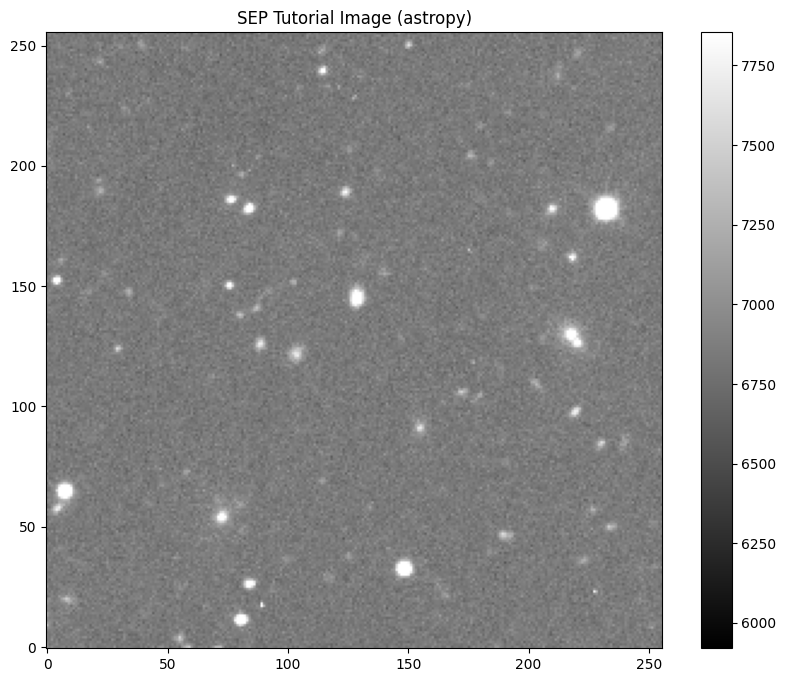

In [145]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

with fits.open("image.fits") as hdul:
    data = hdul[0].data.astype(np.float32)

data = np.ascontiguousarray(data)

m, s = np.mean(data), np.std(data)
plt.imshow(data, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.title("SEP Tutorial Image (astropy)")
plt.show()


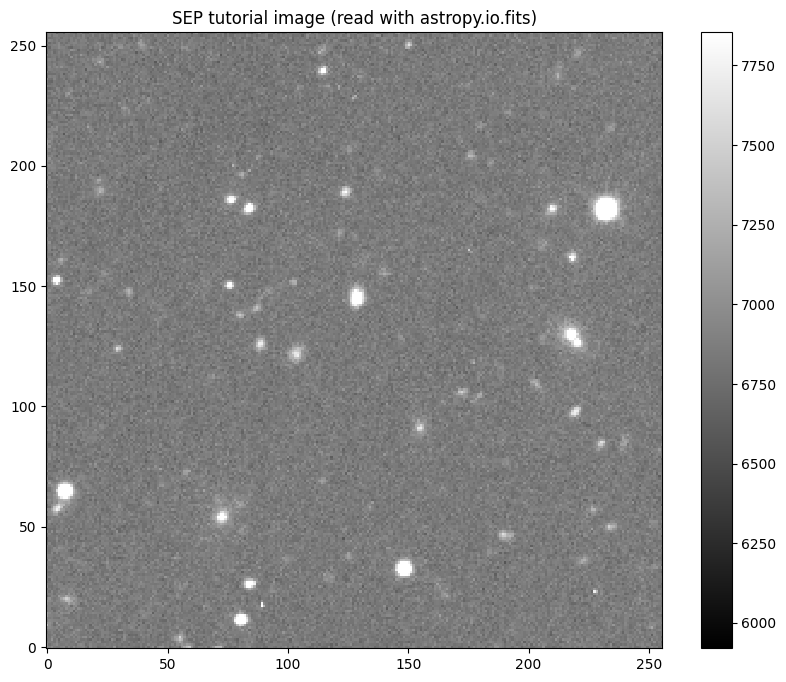

In [146]:

with fits.open("image.fits") as hdul:
    data = hdul[0].data.astype(np.float32)

data = np.ascontiguousarray(data)
m, s = np.mean(data), np.std(data)
plt.imshow(
    data,
    interpolation='nearest',
    cmap='gray',
    vmin=m - s,
    vmax=m + s,
    origin='lower'
)
plt.colorbar()
plt.title("SEP tutorial image (read with astropy.io.fits)")
plt.show()


Global background level: 6852.04931640625
Global background RMS: 65.46174621582031


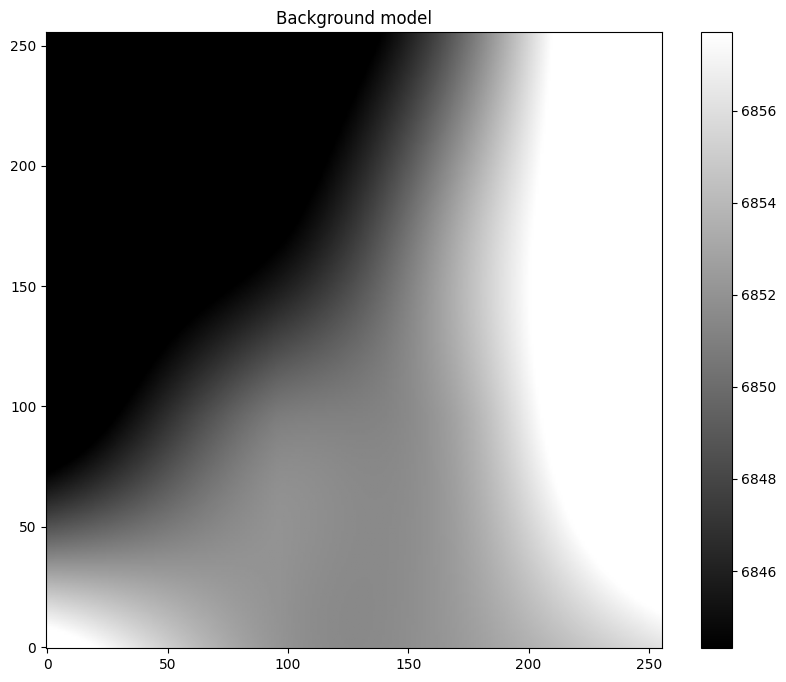

In [147]:
import sep


bkg = sep.Background(data)

print("Global background level:", bkg.globalback)
print("Global background RMS:", bkg.globalrms)


bkg_image = bkg.back()
m, s = np.mean(bkg_image), np.std(bkg_image)
plt.imshow(bkg_image, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.title("Background model")
plt.savefig("tutorial_fig2_background.png", dpi=150)
plt.show()


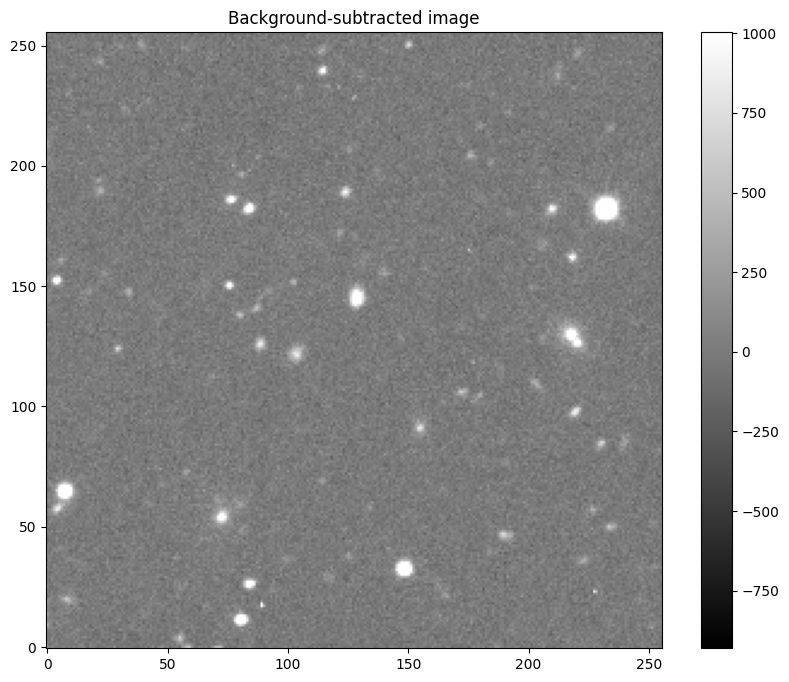

In [148]:

data_sub = data - bkg


m, s = np.mean(data_sub), np.std(data_sub)
plt.imshow(data_sub, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.title("Background-subtracted image")
plt.savefig("tutorial_fig3_background_subtracted.png", dpi=150)
plt.show()


In [149]:

objects = sep.extract(data_sub, 1.5, err=bkg.rms())

print("Number of detected objects:", len(objects))


objects[:5]


Number of detected objects: 76


array([(101.38578796, 13,  7, 68, 73,  0,  2, 71.03719841,  0.50009634, 1.61499012, 0.38042705,  0.10598075, 0.0493983 , 0.01185897,  0.00475909, 1.27437115, 0.60942203,  0.08501586, 0.63072956, 2.67757511, -0.35142186,  1670.64709473,  2254.75976562,  246.18688965,   478.57861328, 71,  0, 72,  0, 2),
       (101.44582367, 11,  9, 56, 60,  0,  2, 58.22105287,  0.36498433, 1.24981079, 0.39973023,  0.05799279, 0.01856998, 0.00872618,  0.0023169 , 1.11970925, 0.62912017,  0.06780168, 0.80554396, 2.51864243, -0.23373635,  2000.08166504,  2664.34228516,  295.52734375,   585.77441406, 58,  0, 59,  0, 3),
       (101.44582367, 36, 22, 52, 58,  0,  8, 55.16181962,  3.51085085, 1.73867963, 2.07574254, -0.04094312, 0.01214318, 0.01622706, -0.00029665, 1.44244397, 1.3167299 , -1.45163453, 0.57541633, 0.48197919,  0.02269967,  6020.38476562,  6388.49804688,  431.04138184,   696.828125  , 55,  4, 55,  4, 1),
       (100.8735199 , 91, 53, 74, 85,  5, 17, 80.41347794, 11.28055884, 2.11661824, 1.90915

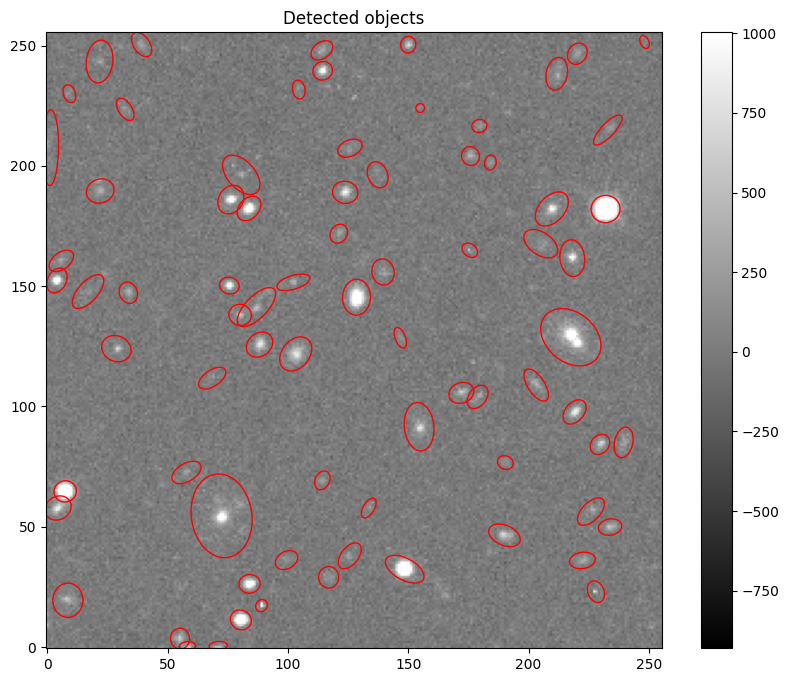

In [150]:
from matplotlib.patches import Ellipse


m, s = np.mean(data_sub), np.std(data_sub)
plt.imshow(data_sub, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()
plt.title("Detected objects")
ax = plt.gca()


for obj in objects:
    e = Ellipse(
        xy=(obj['x'], obj['y']),
        width=6*obj['a'],
        height=6*obj['b'],
        angle=obj['theta'] * 180.0 / np.pi,
        edgecolor='red',
        facecolor='none',
        linewidth=1.0
    )
    ax.add_patch(e)
plt.savefig("tutorial_fig4_detected_objects.png", dpi=150)
plt.show()


In [151]:

flux, fluxerr, flag = sep.sum_circle(
    data_sub,
    objects['x'], objects['y'],
    3.0,
    err=bkg.rms(),
    gain=1.0
)

print("First 10 fluxes:", flux[:10])


First 10 fluxes: [ 2245.98136719  3092.22042969  5949.86837891 72688.08728516
  3859.29957031  6406.32300781  2291.04666016 20919.11744141
  2952.66828125  2144.27796875]


In [152]:
plt.savefig("figure1.png", dpi=150)
plt.savefig("tutorial_fig1_original.png", dpi=150)
plt.show()


<Figure size 1000x800 with 0 Axes>

Step 5-6

Filename: hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (3600, 3600)   float32   


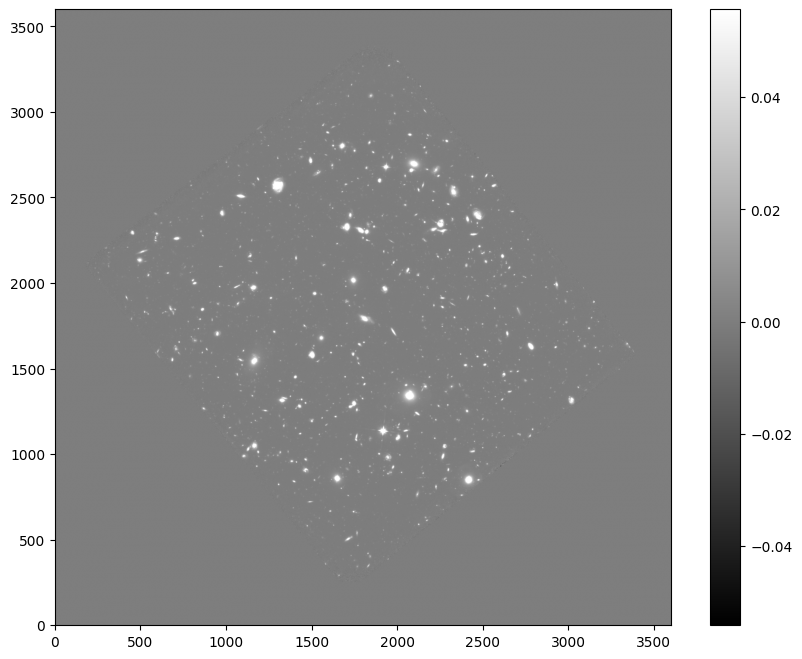

In [154]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

filename = "hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits"


hdul = fits.open(filename)
hdul.info()


data_hudf = hdul[0].data.astype(np.float32)
hdul.close()

data_hudf = np.ascontiguousarray(data_hudf)


m, s = np.mean(data_hudf), np.std(data_hudf)
plt.imshow(data_hudf, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()


Step 6


Number of sources detected: 6090


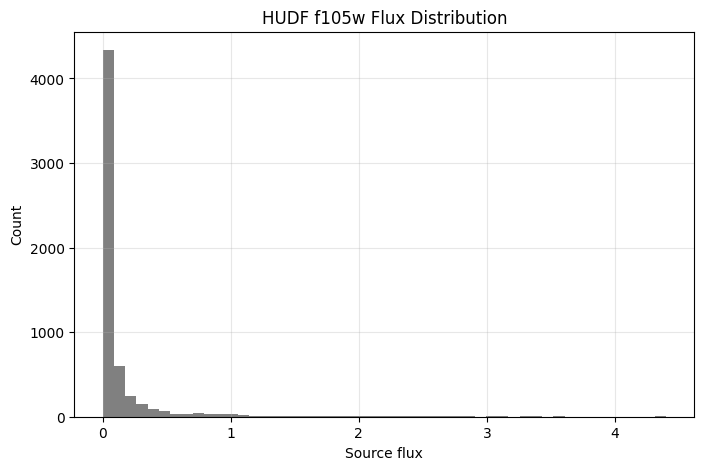

In [156]:
import sep
import numpy as np
import matplotlib.pyplot as plt


bkg_hudf = sep.Background(data_hudf)
bkg_sub = data_hudf - bkg_hudf


objects_hudf = sep.extract(bkg_sub, 1.5, err=bkg_hudf.rms())
print("Number of sources detected:", len(objects_hudf))


flux_hudf, fluxerr_hudf, flag_hudf = sep.sum_circle(
    bkg_sub,
    objects_hudf['x'], objects_hudf['y'],
    3.0,
    err=bkg_hudf.rms()
)


plt.figure(figsize=(8, 5))
plt.hist(flux_hudf, bins=50, range=(0, np.percentile(flux_hudf, 99)), color='gray')
plt.xlabel("Source flux")
plt.ylabel("Count")
plt.title("HUDF f105w Flux Distribution")
plt.grid(alpha=0.3)

plt.savefig("hudf_f105w_flux_histogram.png", dpi=150)
plt.show()


In [157]:

valid_fluxes = flux_hudf[np.isfinite(flux_hudf)]


mean_flux = np.mean(valid_fluxes)
median_flux = np.median(valid_fluxes)
std_flux = np.std(valid_fluxes)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Std dev:", std_flux)


max_index = np.argmax(valid_fluxes)
max_flux = valid_fluxes[max_index]


max_x = objects_hudf['x'][max_index]
max_y = objects_hudf['y'][max_index]


sigma_away = (max_flux - mean_flux) / std_flux

print("\nLARGEST OUTLIER INFORMATION:")
print("Max flux:", max_flux)
print(f"Location on image: (x = {max_x}, y = {max_y})")
print("Sigma above mean:", sigma_away)


Mean flux: 0.4922759254204675
Median flux: 0.036600671541837076
Std dev: 11.001660939759045

LARGEST OUTLIER INFORMATION:
Max flux: 806.8106463623047
Location on image: (x = 1914.2779597971667, y = 1134.3199666722003)
Sigma above mean: 73.29060355995156


Step 8

In [158]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt


f105w = fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")[0].data.astype(np.float32)
f125w = fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f125w_v1.0_drz.fits")[0].data.astype(np.float32)
f160w = fits.open("hlsp_hudf12_hst_wfc3ir_udfmain_f160w_v1.0_drz.fits")[0].data.astype(np.float32)


f105w = np.ascontiguousarray(f105w)
f125w = np.ascontiguousarray(f125w)
f160w = np.ascontiguousarray(f160w)


In [159]:
def scale_image(img, min_percent=0.25, max_percent=99.75, gamma=2.0):

    img = img - np.min(img)


    lo = np.percentile(img, min_percent)
    hi = np.percentile(img, max_percent)
    img = np.clip(img, lo, hi)


    img = (img - lo) / (hi - lo)


    img = img ** (1/gamma)

    return img


In [160]:
R = scale_image(f160w)
G = scale_image(f125w)
B = scale_image(f105w)

rgb = np.zeros((f105w.shape[0], f105w.shape[1], 3))
rgb[..., 0] = R
rgb[..., 1] = G
rgb[..., 2] = B


In [161]:
print("f105w:", np.min(f105w), np.max(f105w), np.mean(f105w))
print("f125w:", np.min(f125w), np.max(f125w), np.mean(f125w))
print("f160w:", np.min(f160w), np.max(f160w), np.mean(f160w))


f105w: -0.9047293 74.44648 0.00079129904
f125w: -0.010169286 70.19213 0.00095716957
f160w: -0.009378761 56.835293 0.0009222782


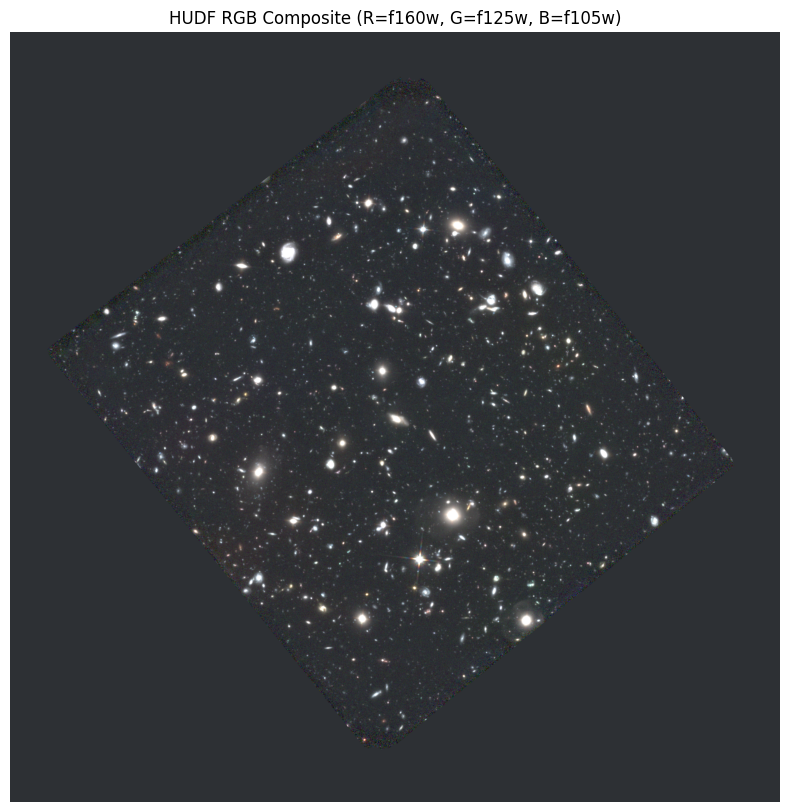

In [162]:
plt.figure(figsize=(10,10))
plt.imshow(rgb, origin='lower')
plt.axis('off')
plt.title("HUDF RGB Composite (R=f160w, G=f125w, B=f105w)")
plt.savefig("HUDF_RGB_f160_f125_f105.png", dpi=200, bbox_inches='tight')
plt.show()
